In [2]:
%pip install nltk
import pandas as pd
import nltk
nltk.download('wordnet')


# Load your raw dataset
raw_data = pd.read_csv("/teamspace/studios/this_studio/yt_true_labels.csv")
youtube_comments_true_df= raw_data

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package wordnet to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
import random
from nltk.corpus import wordnet as wn
from nltk import pos_tag
from nltk.corpus import stopwords
import string

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')


# Separating the majority and minority classes
maj_class = youtube_comments_true_df[youtube_comments_true_df["true_value"] == 0]
min_class = youtube_comments_true_df[youtube_comments_true_df["true_value"] == 1]

# Define stop words and punctuation
stop_words = set(stopwords.words("english"))
punctuation = set(string.punctuation)

def get_wordnet_pos(treebank_tag):
    """Map POS tag to WordNet POS tags."""
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return None

def synonym_replacement(comment, n=1, replace_prob=0.3):
    words = comment.split()
    new_words = words.copy()
    
    # Part-of-speech tagging
    tagged_words = pos_tag(words)
    
    for _ in range(n):
        # Choose a random word to replace
        candidates = [
            (word, get_wordnet_pos(pos))
            for word, pos in tagged_words
            if word.lower() not in stop_words
            and word not in punctuation
            and get_wordnet_pos(pos) is not None
        ]
        if not candidates:
            break  # No replaceable words found
        
        word_to_replace, pos = random.choice(candidates)
        synonyms = wn.synsets(word_to_replace, pos=pos)
        
        if synonyms:
            # Replace with a random synonym
            new_word = random.choice(synonyms).lemmas()[0].name()
            # Replace in the sentence with a probability
            if random.random() < replace_prob:
                new_words[new_words.index(word_to_replace)] = new_word

    return " ".join(new_words)

# Apply synonym replacement to minority class
augmented_minority = min_class.copy()
augmented_minority["Comment"] = augmented_minority["Comment"].apply(lambda x: synonym_replacement(x, n=2, replace_prob=0.5))

# Combine augmented data with original data
balanced_df = pd.concat([maj_class, min_class, augmented_minority])


[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0
Comment
<class 'str'>    474
Name: count, dtype: int64
Phase 1: Training on easy examples
Epoch 1/3, Training Loss: 0.7867
Validation Metrics (Easy Examples):
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        49
           1       0.27      1.00      0.42        18

    accuracy                           0.27        67
   macro avg       0.63      0.50      0.21        67
weighted avg       0.80      0.27      0.11        67

Epoch 2/3, Training Loss: 0.6873
Validation Metrics (Easy Examples):
              precision    recall  f1-score   support

           0       0.73      1.00      0.84        49
           1       1.00      0.00      0.00        18

    accuracy                           0.73        67
   macro avg       0.87      0.50      0.42        67
weighted avg       0.80      0.73      0.62        67

Epoch 3/3, Training Loss: 0.6533
Validation Metrics (Easy Examples):
              precision    recall  f1-score   s

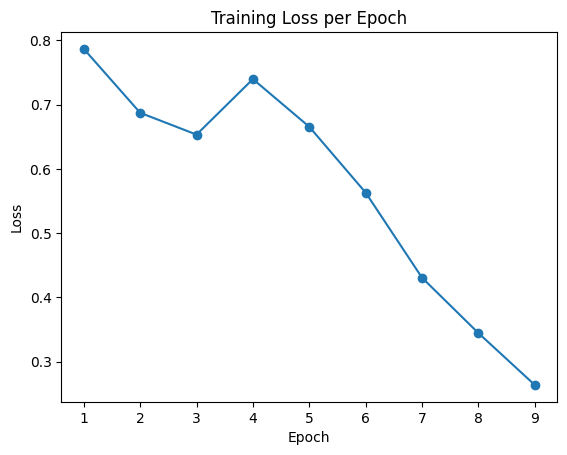

('fine_tuned_hate_speech_model/tokenizer_config.json',
 'fine_tuned_hate_speech_model/special_tokens_map.json',
 'fine_tuned_hate_speech_model/vocab.txt',
 'fine_tuned_hate_speech_model/added_tokens.json',
 'fine_tuned_hate_speech_model/tokenizer.json')

In [11]:
%pip install transformers
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from sklearn.utils.class_weight import compute_class_weight


# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = compute_class_weight('balanced', classes=[0, 1], y=balanced_df["true_value"].values)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

#load tokenizer and model
model_name = "Hate-speech-CNERG/dehatebert-mono-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)


# Check for non-string or NaN values
print(balanced_df["Comment"].isnull().sum())  # Check for missing values
print(balanced_df["Comment"].apply(type).value_counts())  # Check data types

# Handle missing or non-string values
balanced_df["Comment"] = balanced_df["Comment"].fillna("").astype(str)


#curriculum Learning: Sort dataset by comment length
# Assuming 'balanced_df["Comment"]' contains text data (strings)
balanced_df["comment_length"] = balanced_df["Comment"].apply(len)
balanced_df = balanced_df.sort_values("comment_length")


# Custom dataset class
class CommentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        comment = str(self.data.iloc[index]["Comment"])
        label = self.data.iloc[index]["true_value"]
        encoding = self.tokenizer(
            comment,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
        }

# Split into easy and hard subsets
split_point = int(0.7 * len(balanced_df))
easy_df = balanced_df[:split_point]
hard_df = balanced_df[split_point:]

# Create datasets and dataloaders
train_size = int(0.8 * len(easy_df))
val_size = len(easy_df) - train_size

easy_dataset = CommentDataset(easy_df, tokenizer)
hard_dataset = CommentDataset(hard_df, tokenizer)
full_dataset = CommentDataset(balanced_df, tokenizer)

train_easy_dataset, val_easy_dataset = random_split(easy_dataset, [train_size, val_size])

train_easy_loader = DataLoader(train_easy_dataset, batch_size=16, shuffle=True)
val_easy_loader = DataLoader(val_easy_dataset, batch_size=16)
hard_loader = DataLoader(hard_dataset, batch_size=16, shuffle=True)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=True)

# Optimizer
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training function
def train_epoch(model, data_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in data_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    return total_loss / len(data_loader)

# Evaluation function
def eval_model(model, data_loader, device):
    model.eval()
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return true_labels, predictions

# Training with Curriculum Learning and Weighted Loss
train_losses = []

# Phase 1: Easy examples
epochs_per_stage = 3
print("Phase 1: Training on easy examples")
for epoch in range(epochs_per_stage):
    train_loss = train_epoch(model, train_easy_loader, optimizer, device, loss_fn)
    train_losses.append(train_loss)
    print(f"Epoch {epoch + 1}/{epochs_per_stage}, Training Loss: {train_loss:.4f}")

    true_labels, predictions = eval_model(model, val_easy_loader, device)
    print("Validation Metrics (Easy Examples):")
    print(classification_report(true_labels, predictions, zero_division=1))

# Phase 2: Harder examples
print("\nPhase 2: Training on harder examples")
for epoch in range(epochs_per_stage):
    train_loss = train_epoch(model, hard_loader, optimizer, device, loss_fn)
    train_losses.append(train_loss)
    print(f"Epoch {epoch + 1}/{epochs_per_stage}, Training Loss: {train_loss:.4f}")

    true_labels, predictions = eval_model(model, val_easy_loader, device)
    print("Validation Metrics (Harder Examples):")
    print(classification_report(true_labels, predictions, zero_division=1))

# Phase 3: Full dataset fine-tuning
print("\nPhase 3: Fine-tuning on the full dataset")
for epoch in range(epochs_per_stage):
    train_loss = train_epoch(model, full_loader, optimizer, device, loss_fn)
    train_losses.append(train_loss)
    print(f"Epoch {epoch + 1}/{epochs_per_stage}, Training Loss: {train_loss:.4f}")

    true_labels, predictions = eval_model(model, val_easy_loader, device)
    print("Validation Metrics (Full Dataset):")
    print(classification_report(true_labels, predictions, zero_division=1))



# Plotting training loss
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Save the fine-tuned model
model.save_pretrained("fine_tuned_hate_speech_model")
tokenizer.save_pretrained("fine_tuned_hate_speech_model")



In [2]:
import random
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
import string
import nltk
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

torch.cuda.empty_cache()

# Device setup
device = torch.device("cpu")

# Load your raw dataset
file_path = "/teamspace/studios/this_studio/youtube_comments.csv"
raw_data = pd.read_csv(file_path)

# Ensure 'Comment' column is treated as text and handle missing values
raw_data["Comment"] = raw_data["Comment"].fillna("").astype(str)

# Model paths
model_path = "/teamspace/studios/this_studio/fine_tuned_hate_speech_model"
tokenizer_path = "/teamspace/studios/this_studio/fine_tuned_hate_speech_model"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)

# Function to get predictions
def get_predictions_for_df(df, tokenizer, model):
    comments = df["Comment"].tolist()
    encoded_inputs = tokenizer(
        comments,
        max_length=128,
        truncation=True,
        padding=True,
        return_tensors="pt"
    )
    input_ids = encoded_inputs["input_ids"].to(device)
    attention_mask = encoded_inputs["attention_mask"].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    return predictions

# Add predicted_label column
raw_data["predicted_label"] = get_predictions_for_df(raw_data, tokenizer, model)

# Separating the majority and minority classes
maj_class = raw_data[raw_data["predicted_label"] == 0]
min_class = raw_data[raw_data["predicted_label"] == 1]

# Define stop words and punctuation
stop_words = set(stopwords.words("english"))
punctuation = set(string.punctuation)

def synonym_replacement(comment, n=1, replace_prob=0.5):
    words = comment.split()
    if len(words) == 0:
        return comment  # Return the original comment if empty
    
    new_words = words.copy()
    for _ in range(n):
        # Choose a random word
        word_to_replace = random.choice(new_words)
        synonyms = wn.synsets(word_to_replace)  # Find synonyms using WordNet
        
        # Check if synonyms exist and proceed
        if synonyms:
            # Choose a synonym and normalize it
            new_word = random.choice(synonyms).lemmas()[0].name().replace('_', ' ')
            
            # Replace the word if it exists in the list
            try:
                index_to_replace = new_words.index(word_to_replace)
                if random.random() < replace_prob:
                    new_words[index_to_replace] = new_word
            except ValueError:
                continue  # Skip if the word isn't found in the list

    return " ".join(new_words)

# Apply synonym replacement to minority class
augmented_minority = min_class.copy()
augmented_minority["Comment"] = augmented_minority["Comment"].apply(lambda x: synonym_replacement(x, n=2, replace_prob=0.5))

# Combine augmented data with original data
balanced_df1 = pd.concat([maj_class, min_class, augmented_minority])

# Evaluation
def data_generator(df, batch_size=64):
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i + batch_size]
        yield batch["Comment"].tolist(), batch["predicted_label"].tolist()

def evaluate_model_in_chunks(model, tokenizer, data_gen):
    all_predictions = []
    all_labels = []

    for comments, labels in data_gen:
        predictions = get_predictions_for_df(pd.DataFrame({"Comment": comments}), tokenizer, model)
        all_predictions.extend(predictions)
        all_labels.extend(labels)

    return all_predictions, all_labels

# Evaluate the model
data_gen = data_generator(balanced_df1, batch_size=64)
predictions, true_labels = evaluate_model_in_chunks(model, tokenizer, data_gen)

# Compute metrics
report = classification_report(true_labels, predictions, zero_division=1)
accuracy = accuracy_score(true_labels, predictions)
print("Classification Report:\n", report)
print("Accuracy:", accuracy)


[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     52852
           1       1.00      0.98      0.99       916

    accuracy                           1.00     53768
   macro avg       1.00      0.99      0.99     53768
weighted avg       1.00      1.00      1.00     53768

Accuracy: 0.9996280315429251


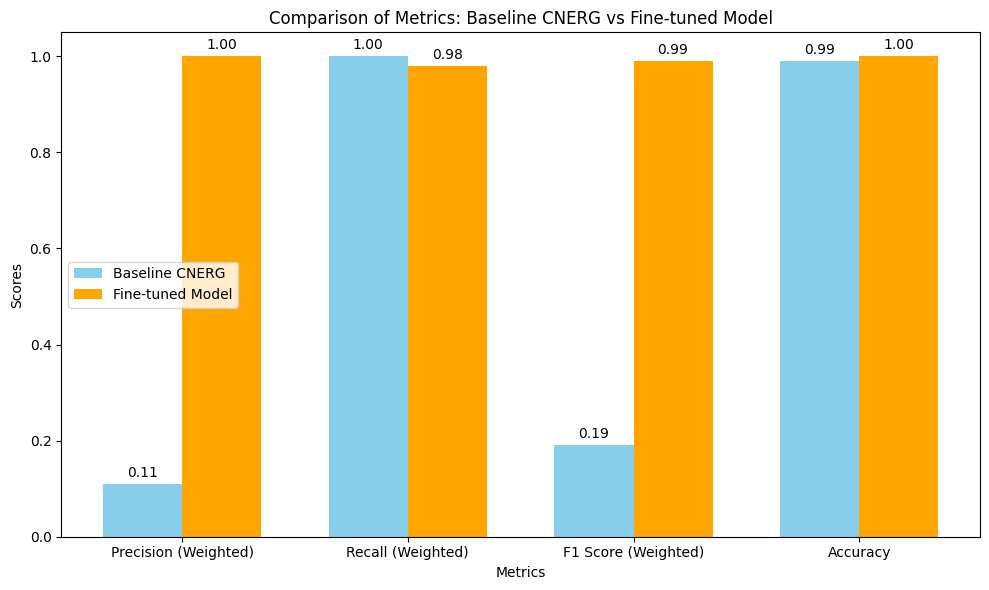

In [3]:
import matplotlib.pyplot as plt
import numpy as np

#define metrics for baseline and fine-tuned models
metrics = ["Precision (Weighted)", "Recall (Weighted)", "F1 Score (Weighted)", "Accuracy"]

#use metrics from previous baseline evaluation
baseline_metrics = {
    "Precision (Weighted)": 0.11,
    "Recall (Weighted)": 1.00,
    "F1 Score (Weighted)": 0.19,
    "Accuracy": 0.99
}

fine_tuned_metrics = {
    "Precision (Weighted)": 1.00,
    "Recall (Weighted)": 0.98,
    "F1 Score (Weighted)": 0.99,
    "Accuracy": 1.00
}

# Extract values for plotting
baseline_values = [baseline_metrics[metric] for metric in metrics]
fine_tuned_values = [fine_tuned_metrics[metric] for metric in metrics]

# Plot metrics
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_values, width, label="Baseline CNERG", color="skyblue")
rects2 = ax.bar(x + width/2, fine_tuned_values, width, label="Fine-tuned Model", color="orange")

# Add labels, title, and legend
ax.set_xlabel("Metrics")
ax.set_ylabel("Scores")
ax.set_title("Comparison of Metrics: Baseline CNERG vs Fine-tuned Model")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add value annotations
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

# Show plot
plt.tight_layout()
plt.show()
